# **BaseLine Mode Implementation**

## **Data load and configuration**

In [107]:
# loading the libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [108]:
# load the dataset
df = pd.read_parquet("/content/nrldc_cleaned.parquet", engine="pyarrow")

In [109]:
# inspecting dataset
df.head()

,actual_demand_mw
datetime,
2024-04-01 00:00:00,45961.6
2024-04-01 00:15:00,45602.8
2024-04-01 00:30:00,45311.8
2024-04-01 00:45:00,44968.8
2024-04-01 01:00:00,44595.5


In [110]:
df.isnull().sum()

,0
actual_demand_mw,1


Orginal data had, one negative vlaue so adjust with nan. That's why showing null value in 1

In [111]:
df.index.duplicated().sum()

np.int64(0)

Confirm no duplicates

<Axes: xlabel='datetime'>

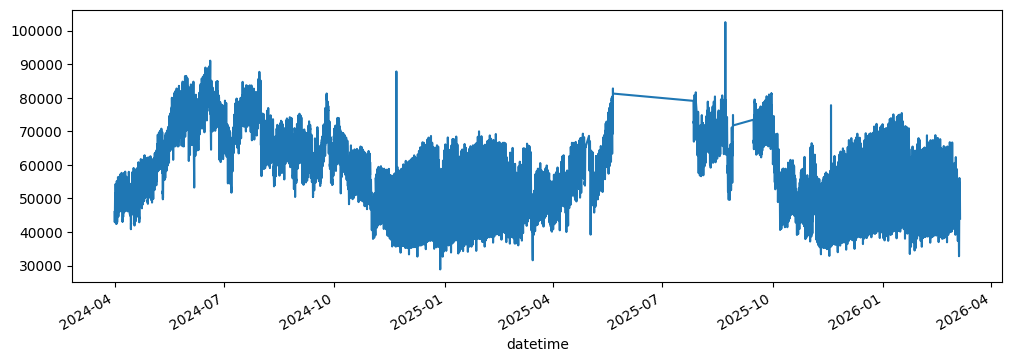

In [112]:
# plotting the trend
df['actual_demand_mw'].plot(figsize=(12,4))

## **Naive Baseline**

**What Nave Baseline model do?**
> It simply computes `Next Load = Current Load`

In [ ]:
# train-test split
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [ ]:
# naive prediction
naive_pred = test['actual_demand_mw'].shift(1)

In [ ]:
# first prediction = last value from train
naive_pred.iloc[0] = train['actual_demand_mw'].iloc[-1]

In [ ]:
# evaluation
mae = mean_absolute_error(test['actual_demand_mw'], naive_pred)
mse = mean_squared_error(test['actual_demand_mw'], naive_pred)
rmse = np.sqrt(mse)

print("Naive Baseline")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Naive Baseline
MAE: 762.85
RMSE: 1024.26


##**Seasonal Naive Baseline**

**What Nave Seasonal Naive Baseline model do?**
> It simply computes `Next Load = Load from same time yesterday`

In [ ]:
# data is of 15 min timestamp; 1D = 96 steps
season_length = 96

In [ ]:
# shifiting values
seasonal_pred = test['actual_demand_mw'].shift(season_length)

In [ ]:
# fill the missing predictions
seasonal_pred.iloc[:season_length] = train['actual_demand_mw'].iloc[-season_length:].values

In [ ]:
# evaluation
mae = mean_absolute_error(test['actual_demand_mw'], seasonal_pred)
rmse = np.sqrt(mean_squared_error(test['actual_demand_mw'], seasonal_pred))

print("Seasonal Naive Baseline")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Seasonal Naive Baseline
MAE: 1767.46
RMSE: 2755.67


## **Insight from baseline model:**
---
* **Naive Baseline**
  * MAE: 762.85
  * RMSE: 1024.26
  > Indicates relatively lower error compared to the seasonal approach, serving as a reasonable benchmark.

* **Seasonal Naive Baseline**
  * MAE: 1767.46
  * RMSE: 2755.67
  > Significantly higher error, suggesting that seasonal repetition alone does not capture the underlying data patterns effectively.